# Ensemble Analysis

This notebook reads in and formats outputs from ensemble simulations so that you can evaluate and plot

### Import packages

In [1]:
#import packages
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mp
import pandas as pd
import numpy as np
import os


#additional analysis tools
import flopy.utils.binaryfile as bf
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from IPython.display import display  # <- key


np.set_printoptions(threshold=np.inf)

#jupyter specific--included to show plots in notebook
%matplotlib inline 

# Setup static variables

In [2]:
nrow = 50       #number of rows
ncol = 50       #number of columns
nlay = 3        #number of layers
dx= 1000        #width of grid cells in x direction 
dy= 1000        #width of grid cells in y direction 
Lx = ncol*dx    #width of domain in x
Ly = nrow*dy    #width of domain in y

ens_lst = ["1111331", "1131331", "1133113", "1323131", "1213121", "1211311", "1113111", "3311113", "1111111", "3333113"]

ens_set = set(ens_lst)

ensembles = [[int(e) for e in ens ] for ens in ens_lst]

n_ens = len(ensembles)
n_enset = len(ens_set)

# print(n_ens, 'Ensembles to evaluate', n_enset)


## Read in outputs across all ensemble members and store as arrays 

In [3]:
#setup arrays to store the values
head_array =        np.zeros((len(ensembles), nlay, ncol, nrow))
frf_array =         np.zeros((len(ensembles),  nlay, ncol, nrow))
fff_array =         np.zeros((len(ensembles),  nlay, ncol, nrow))
recharge_array =    np.zeros((len(ensembles),  1, ncol, nrow))
et_array =          np.zeros((len(ensembles),  1, ncol, nrow))
stor_array =        np.zeros((len(ensembles),  1, ncol, nrow))
leakage_array =     np.zeros((len(ensembles), 49)) #Note this is the only array that is 2D

# Loop through the ensembles and read the data
root_name = 'static_ensemble_' #root of the run names
# root_name = 'static_ensemble_S1bc_' #root of the run names
# root_name = 'static_ensemble_S2wel_' #root of the run names
for i in range(len(ensembles)):
    # print('Assembling outputs for simulation ', i+1, ' of ', len(ensembles))
    name = root_name  #Create the file name from list 
    for k in range(len(ensembles[i])):
        string = str(ensembles[i][k])
        name = name + string   

    #read in the head and water budget files
    headobj = flopy.utils.binaryfile.HeadFile(name+'.hds')
    budgobj = flopy.utils.binaryfile.CellBudgetFile(name+'.cbc') 
    
    head_array[i, :, :, :] = headobj.get_data(totim=1.0)
        
    tempfrf = np.squeeze(budgobj.get_data(text='flow right face', totim=1.0))
    frf_array[i, :, :, :] = tempfrf
        
    tempfff = np.squeeze(budgobj.get_data(text='FLOW FRONT FACE', totim=1.0))
    fff_array[i, :, :, :] = tempfff

    temprch = np.squeeze(budgobj.get_data(text='RECHARGE', totim=1.0))
    recharge_array[i,  :, :, :] = temprch[1]

    tempet = np.squeeze(budgobj.get_data(text='ET', totim=1.0))
    et_array[i, :, :, :] = tempet[1]

    templeak = budgobj.get_data(text='RIVER LEAKAGE', totim=1.0)
    leakage_array[i, :] = templeak[0].q
    # budgobj = CellBudgetFile(...)

    chd3d = budgobj.get_data(text="CONSTANT HEAD", totim=1.0, full3D=True)[0]  # (nlay,nrow,ncol)

    left_chd_flux_total = chd3d[:, :, 0].sum()   # all layers/rows, left boundary column j=0
    right_chd_flux_total = chd3d[:, :, -1].sum() # right boundary column j=-1 (if CHD there too)

    print("Left boundary CHD flux (sum):", left_chd_flux_total)
    print("Right boundary CHD flux (sum):", right_chd_flux_total)

    k, i, j = 0, 21, 38
    print("Mean FRF at well cell:", frf_array[:, k, i, j].mean())  # if frf_array is (nens,nlay,nrow,ncol)

flux_list = []
hds_list  = []

ens_dirs = ["static_ensemble_", "static_ensemble_S1bc_", "static_ensemble_S2wel_"]
nens = len(ensembles)

# # --- (optional) infer grid shape once from the first file ---
# first_name = ens_dirs[0] + "".join(map(str, ensembles[0]))
# headobj0 = flopy.utils.binaryfile.HeadFile(first_name + ".hds")
# sample = headobj0.get_data(totim=1.0)          # (nlay, nrow, ncol)
# nlay, nrow, ncol = sample.shape

for ens_prefix in ens_dirs:
    # fresh arrays PER CASE
    head_array = np.empty((nens, nlay, nrow, ncol), dtype=np.float32)
    frf_array  = np.empty((nens, nlay, nrow, ncol), dtype=np.float32)

    for i in range(nens):
        name = ens_prefix + "".join(map(str, ensembles[i]))

        headobj = flopy.utils.binaryfile.HeadFile(name + ".hds")
        head_array[i, :, :, :] = headobj.get_data(totim=1.0)

        budgobj = flopy.utils.binaryfile.CellBudgetFile(name + ".cbc")
        tempfrf = np.squeeze(budgobj.get_data(text="flow right face", totim=1.0))
        frf_array[i, :, :, :] = tempfrf

    # append ONCE per case (and use copy() to avoid mutation issues)
    hds_list.append(head_array.copy())
    flux_list.append(frf_array.copy())

# Now you have exactly 3 cases:
baseline = hds_list[0]
S1bc     = hds_list[1]
S2wel    = hds_list[2]

head_change = [S1bc - baseline, S2wel - baseline]   # length 2 ✅

Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): 1974.5614
Mean FRF at well cell: 0.6396771907806397
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): 1974.5614
Mean FRF at well cell: 1.2793543815612793
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): -12317.343
Mean FRF at well cell: 5.581313991546631
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): -14062.344
Mean FRF at well cell: 0.4088454246520996
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): -14177.957
Mean FRF at well cell: -4.165039539337158
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): 687.8003
Mean FRF at well cell: -15.469955921173096
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): -14568.574
Mean FRF at well cell: -6.049686145782471
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): -267338.12
Mean FRF at well cell: 49.605727672576904
Left boundary CHD flux (sum): --
Right boundary CHD flux (sum): -513

## Examples grabbing out values of interest from arrays
See below for some examples grabbing out values of interest. I'm not plotting them here you can either plot them in python or just copy values into excel for your plotting. 

### Notes: 
1. Remeber for all arrays except for river leakage the structure is: array_name[ensemble_number, vertical_layer, row, column]
2. River Leakage only has values for the river cells so its structure is: leakage_array[ensemble_number, column]
3. I have provided ET as an example here. There are arrays for fluxes recharge, head and storage that all have the same structure so you can just swap out the et_array name for one of the other names (e.g. 'head_array') to get values for that out. 

In [4]:
#print out the values for any of the stored arrays for all ensemble members. Every example below will print out one number for each ensemble member. 

#  ET at a single location in this case row 22, column 15
et_sigle_loc = et_array[:, 0, 22, 15]
print("ET at one location:")
print(", ".join(str(round(n, 2)) for n in et_sigle_loc))

# ET summed across the domain
# Note here I am summing for all rows and all columns but you could change sum across any area by changing the row and column ranges provided
et_sum=np.zeros(len(ensembles))
for i in range(len(ensembles)):
    et_sum[i]= np.sum(et_array[i, 0, :,:])
print("\nTotal ET:")
print(", ".join(str(round(n, 2)) for n in et_sum))

#  River leakage a single location, column 25
leak_sigle_loc = leakage_array[:, 25]
print("\nLeakage at one location:")
print(", ".join(str(round(n, 2)) for n in leak_sigle_loc))

#  River leakage a single location, column 25
leak_total = np.sum(leakage_array, axis=1)
print("\nTotal Leakage:")
print(", ".join(str(round(n, 2)) for n in leak_total))

ET at one location:
0.0, 0.0, -1.0, -3.0, -2.0, 0.0, -1.0, -0.83, -0.25, -0.84

Total ET:
-9469.55, -9469.55, -553.93, -1300.1, -983.93, -8182.79, -695.01, -441.26, -280.23, -445.47

Leakage at one location:
125.0, 125.0, -349.16, -388.77, -393.13, 125.0, -330.94, -7436.14, -21.53, -7727.06

Total Leakage:
6000.0, 6000.0, -14703.7, -12212.54, -12413.1, 6000.0, -12311.39, 266285.33, 3919.22, 242274.92


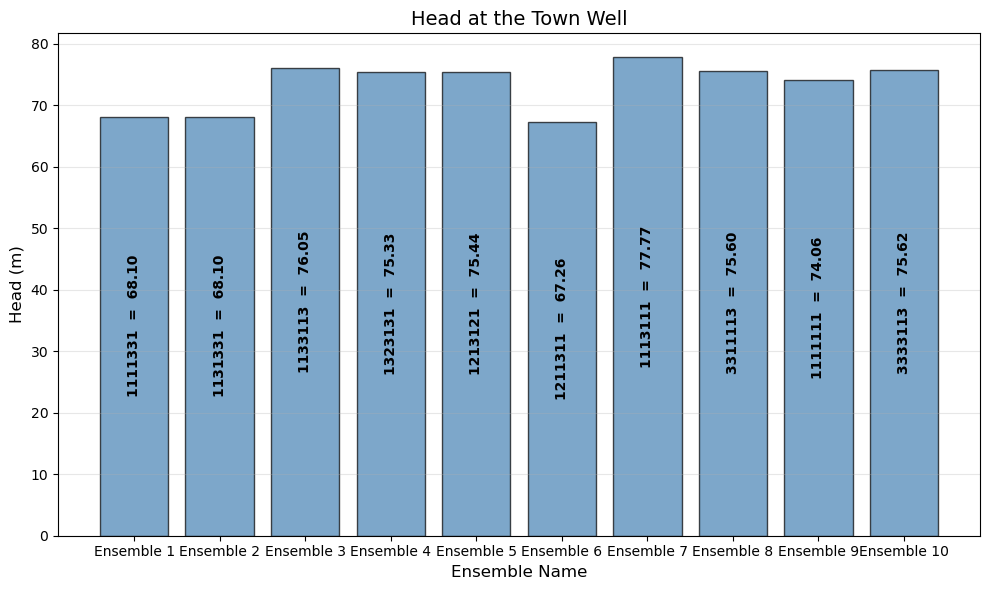

Ranked Head values at location (0, 21, 38)
from Greatest loss to Least Loss:


,Rank,Name,Ensemble,Head (m)
0,1.00,Ensemble 6,1211311,67.26
1,2.00,Ensemble 1,1111331,68.10
2,3.00,Ensemble 2,1131331,68.10
3,4.00,Ensemble 9,1111111,74.06
4,5.00,Ensemble 4,1323131,75.33
5,6.00,Ensemble 5,1213121,75.44
6,7.00,Ensemble 8,3311113,75.60
7,8.00,Ensemble 10,3333113,75.62
8,9.00,Ensemble 3,1133113,76.05
9,10.00,Ensemble 7,1113111,77.77


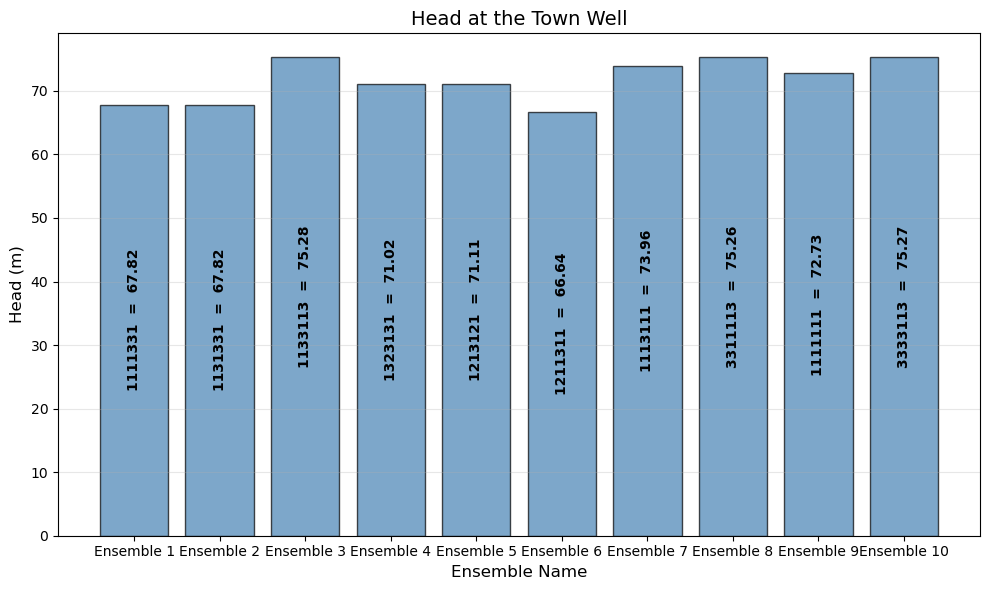

Ranked Head values at location (0, 21, 38)
from Greatest loss to Least Loss:


,Rank,Name,Ensemble,Head (m)
0,1.00,Ensemble 6,1211311,66.64
1,2.00,Ensemble 1,1111331,67.82
2,3.00,Ensemble 2,1131331,67.82
3,4.00,Ensemble 4,1323131,71.02
4,5.00,Ensemble 5,1213121,71.11
5,6.00,Ensemble 9,1111111,72.73
6,7.00,Ensemble 7,1113111,73.96
7,8.00,Ensemble 8,3311113,75.26
8,9.00,Ensemble 10,3333113,75.27
9,10.00,Ensemble 3,1133113,75.28


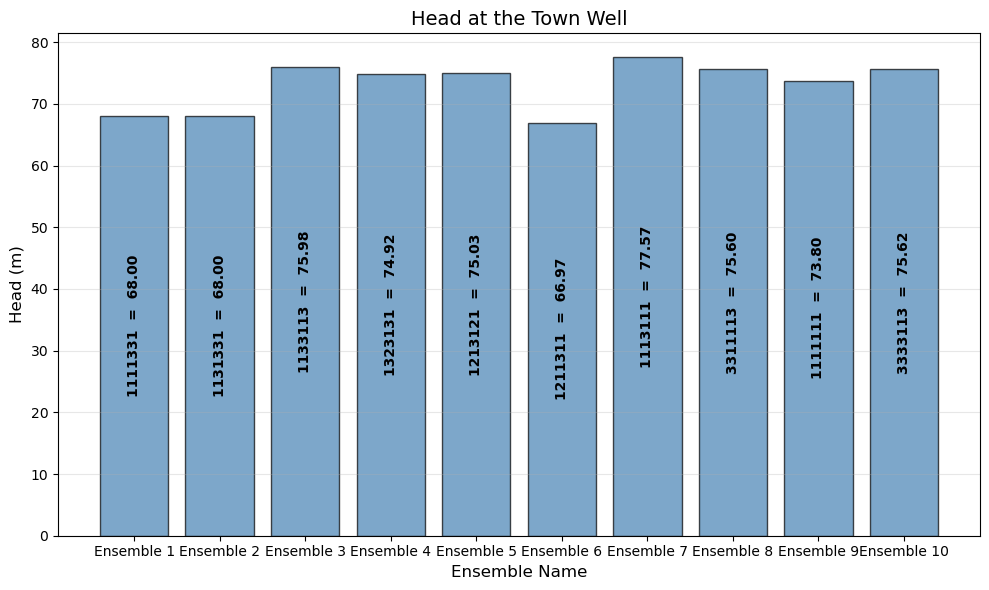

Ranked Head values at location (0, 21, 38)
from Greatest loss to Least Loss:


,Rank,Name,Ensemble,Head (m)
0,1.00,Ensemble 6,1211311,66.97
1,2.00,Ensemble 1,1111331,68.00
2,3.00,Ensemble 2,1131331,68.00
3,4.00,Ensemble 9,1111111,73.80
4,5.00,Ensemble 4,1323131,74.92
5,6.00,Ensemble 5,1213121,75.03
6,7.00,Ensemble 8,3311113,75.60
7,8.00,Ensemble 10,3333113,75.62
8,9.00,Ensemble 3,1133113,75.98
9,10.00,Ensemble 7,1113111,77.57


In [5]:
head_change = [head - hds_list[0] for head in hds_list[1:]]
dfs = []
for head in hds_list: # Extract head at the specified well location for each ensemble member well_loc = (0, 21, 38)  # (layer, row, column) head_at_well = head[:, well_loc[0], well_loc[1], well_loc[2]]
    # Extract head at the specified well location for each ensemble member
    well_loc = (0, 21, 38)  # (layer, row, column)
    head_at_well = head[:, well_loc[0], well_loc[1], well_loc[2]]

    # Create ensemble names
    ensemble_names = [f'Ensemble {i+1}' for i in range(len(ensembles))]
    # Create the plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(ensemble_names, head_at_well, color='steelblue', edgecolor='black', alpha=0.7)
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
            height / 2,                         # Y position (middle of bar)
            f'{ens_lst[i]}  =  {height:.2f}',   # Text to display
            ha='center',                        # Horizontal alignment
            va='center',                        # Vertical alignment
            rotation=90,                        # Rotate text vertically
            color='black',                      # Text color
            fontsize=10,                        # Font size
            fontweight='bold'                   # Bold text
        )

    plt.xlabel('Ensemble Name', fontsize=12)
    plt.ylabel('Head (m)', fontsize=12)
    plt.title(f'Head at the Town Well', fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


    zipped = list(zip(ensemble_names, head_at_well, ens_lst))
    sorted_by_hds = sorted(zipped, key=lambda x: x[1])

    print(f"Ranked Head values at location {well_loc}\nfrom Greatest loss to Least Loss:")

    rows = []
    for i, (name, head, ensemble) in enumerate(sorted_by_hds, start=1):
        rows.append({"Rank": i, "Name": name, "Ensemble": ensemble, "Head (m)": head})

    results_table = pd.DataFrame(rows)
    styled = results_table.style.format({col: "{:,.2f}" for col in results_table.select_dtypes(include="number").columns})

    display(styled)   # <- this is what makes it show